# Ames Housing Price Prediction Using Multiple Linear Regression

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 The dataset contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

This project develops a multiple linear regression model to predict residential sale prices in Ames, Iowa. The workflow includes data cleaning, exploratory data analysis, feature selection, model training, and evaluation using regression performance metrics.

## Workflow

1. Load and inspect the data
2. Clean and prepare the dataset
3. Perform exploratory data analysis
4. Select relevant features
5. Train a multiple linear regression model
6. Evaluate model performance
7. Interpret the results

## Import Libraries

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Data

In [12]:
df = pd.read_csv('ames.csv')
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


## Dataset Cleaning

In [13]:
# Clean and preprocess the data if neccessary
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB


,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1971.356314,1984.266553,1051.255631,1159.557679,335.455973,1499.690444,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,472.658362,180796.060068
std,30.245361,20.860286,440.968018,391.890885,428.395715,505.508887,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,215.187196,79886.692357
min,1872.000000,1950.000000,0.000000,334.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,12789.000000
25%,1954.000000,1965.000000,793.000000,876.250000,0.000000,1126.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,320.000000,129500.000000
50%,1973.000000,1993.000000,990.000000,1084.000000,0.000000,1442.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,480.000000,160000.000000
75%,2001.000000,2004.000000,1301.500000,1384.000000,703.750000,1742.750000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,576.000000,213500.000000
max,2010.000000,2010.000000,6110.000000,5095.000000,2065.000000,5642.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,1488.000000,755000.000000


The dataset contains 2930 observations and 14 numerical variables. There are no missing values, indicating that the dataset is complete and does not require imputation before analysis. This allows the modelling process to proceed without additional preprocessing related to missing data.

## Exploratory Data Analysis

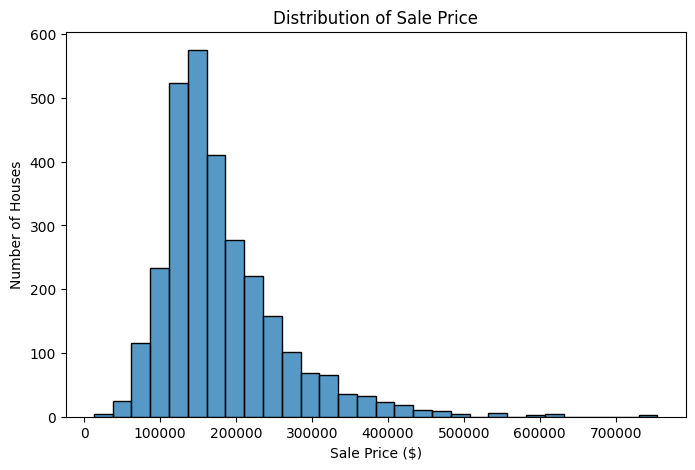

In [14]:
# Distribution of the dependent variable (Sale_Price)
plt.figure(figsize=(8,5))
sns.histplot(df['Sale_Price'], bins=30)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.show()

The distribution of sale prices is positively skewed, with most properties selling between approximately 100,000 dollars and 200,000 dollars. A smaller number of high-value properties create a long right tail, indicating that extremely expensive homes are relatively uncommon.

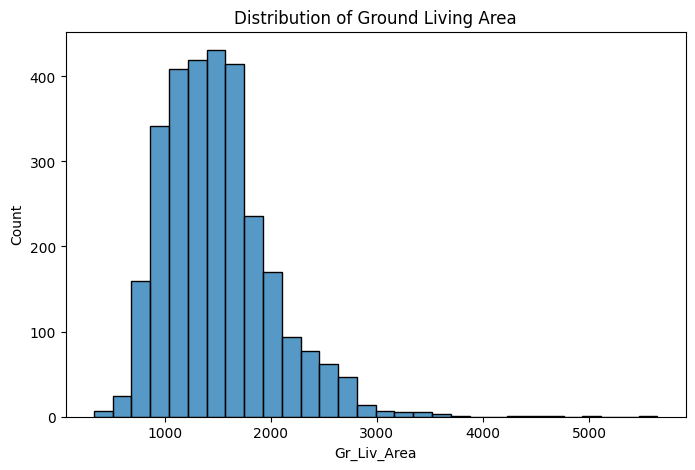

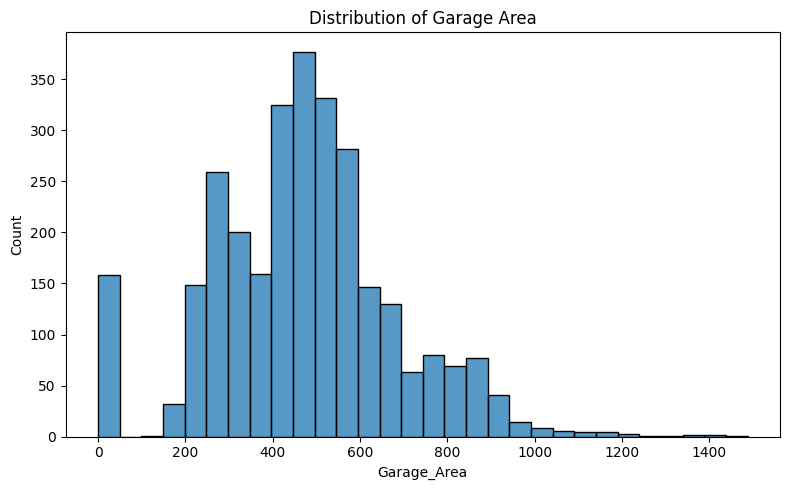

In [15]:
## Distribution of independent variables (Gr_Liv_Area, Garage_Area)
plt.figure(figsize=(8,5))
sns.histplot(df['Gr_Liv_Area'], bins=30)
plt.title('Distribution of Ground Living Area')

plt.figure(figsize=(8,5))
sns.histplot(df['Garage_Area'], bins=30)
plt.title('Distribution of Garage Area')

plt.tight_layout()
plt.show()

**Ground Living Area**

Most homes have between 1,000 and 2,000 square feet of above-ground living space. The distribution is slightly right-skewed, with relatively few very large homes. This suggests that the majority of properties are of moderate size.

**Garage Area**

Garage sizes are concentrated around typical residential values, with fewer properties having exceptionally large garages. This variation may help explain differences in house prices.

## Relationship between independent and dependent variables

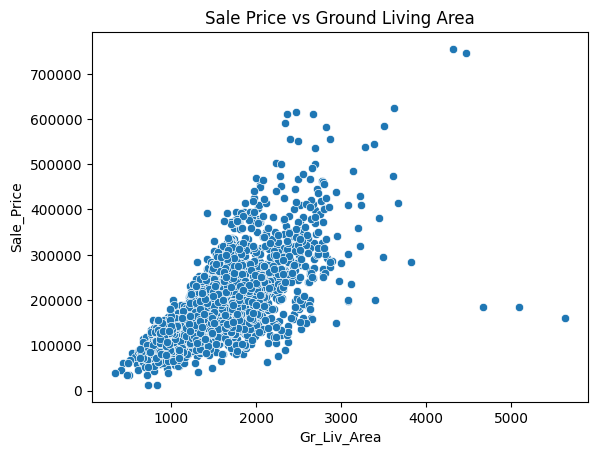

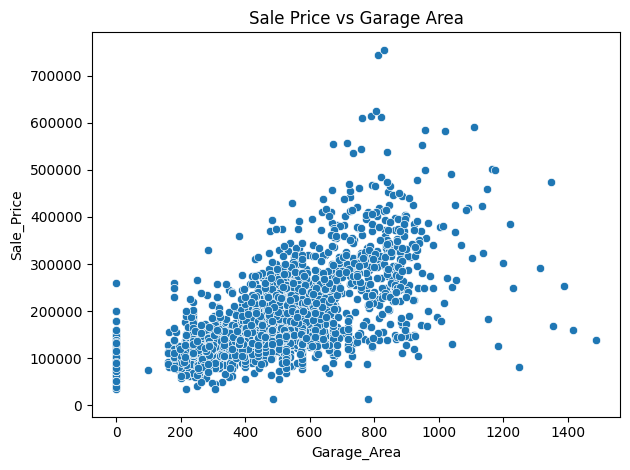

In [16]:
# Generate plots to explore the relationships between the independent and dependent variables
plt.figure()
sns.scatterplot(x='Gr_Liv_Area', y='Sale_Price', data=df)
plt.title('Sale Price vs Ground Living Area')

plt.figure()
sns.scatterplot(x='Garage_Area', y='Sale_Price', data=df)
plt.title("Sale Price vs Garage Area")

plt.tight_layout()

**Ground Living Area**

The scatter plot shows a clear positive linear relationship between above-ground living area and sale price. Larger homes generally sell for higher prices, although there is some variability. This indicates that living area is likely to be an important predictor in the regression model.

**Garage Area**

Garage area also shows a positive relationship with sale price, although the relationship appears weaker than that of living area. This suggests that garage size contributes to property value but may have less predictive power.

## Feature Selection

In [17]:
# Split the independent variables from the dependent variable
X = df[['Gr_Liv_Area', 'Garage_Area']]
y = df['Sale_Price']

For the regression model, the independent variables are Gr_Liv_Area and Garage_Area. These variables represent the size of the living area and garage, both of which are expected to influence house sale prices. The dependent variable is Sale_Price, which the model will attempt to predict.

## Training-Test Split

In [18]:
# Create a training and test set with a 75:25 split ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 2197
Test set size: 733


The dataset was split into training and test sets using a 75:25 ratio. This ensures that the model is trained on most of the data while reserving a portion for unbiased evaluation. A fixed random state was used to guarantee reproducibility of results.

## Regression Model

A multiple linear regression model was trained using the selected predictor variables (Gr_Liv_Area and Garage_Area). The model was fitted on the training dataset to learn the relationship between these housing characteristics and sale price.

In [19]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


A multiple linear regression model was built using the training set, with Gr_Liv_Area and Garage_Area as predictors. The model was fitted to the training data, producing an intercept and coefficients that represent the estimated effect of each variable on Sale_Price.

In [20]:
# Print the trained model's intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -5059.448195610428
Coefficients: [ 78.69286848 141.14571761]


The regression model produced an intercept of -5059.45. This represents the sale price when both Gr_Liv_Area and Garage_Area are zero.

The coefficient for Gr_Liv_Area is 78.69, meaning that for each additional square foot of above-grade living area, the model predicts an increase of 78.69 in sale price, holding garage area constant.

The coefficient for Garage_Area is 141.15, meaning that for each additional square foot of garage space, the model predicts an increase of 141.15 in sale price, holding living area constant.

## Predictions

In [21]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

print("Predicted values:", y_pred[:5])
print("Actual values:", y_test[:5].values)

Predicted values: [158224.09430889 113256.67578876 217552.81911301  72846.49160079
  94782.71287234]
Actual values: [161000 116000 196500 123600 126000]


The trained regression model was applied to the test set to generate predicted sale prices. These predictions can be compared with the actual sale prices to evaluate how well the model generalizes to unseen data. A preview of the predicted and actual values confirms that the model produces reasonable estimates, though differences remain due to variability in housing features not included in the model.

## Model Evaluation

In [25]:
# Evaluate the model's performance by computing the MAE, MSE, RMSE, and the R^2 on the test set.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): $33,476.85
Mean Squared Error (MSE): 2,634,371,879.69
Root Mean Squared Error (RMSE): $51,326.13
R² Score: 0.639


The model achieved a **Mean Absolute Error (MAE)** of approximately **\$33,477**, indicating that, on average, the predicted sale prices differ from the actual sale prices by around \$33,000.

The **Mean Squared Error (MSE)** was **2,634,371,880**. Because the errors are squared, this metric places greater emphasis on larger prediction errors and is primarily useful for comparing models rather than interpreting prediction accuracy directly.

The **Root Mean Squared Error (RMSE)** was approximately **\$51,326**, meaning the model's predictions typically deviate from the actual sale prices by about \$51,000. Since RMSE penalises larger errors more heavily than MAE, the difference between these two metrics suggests that the model makes some relatively large prediction errors.

The model achieved an **R² score of 0.639**, indicating that approximately 63.9% of the variation in house sale prices is explained by the selected predictor variables (`Gr_Liv_Area` and `Garage_Area`). While this demonstrates that the model captures a substantial proportion of the variation in sale prices, there is still room for improvement by incorporating additional relevant features.

## Predicted vs Actual Values

Text(0.5, 1.0, 'Predicted vs Actual Sale Prices')

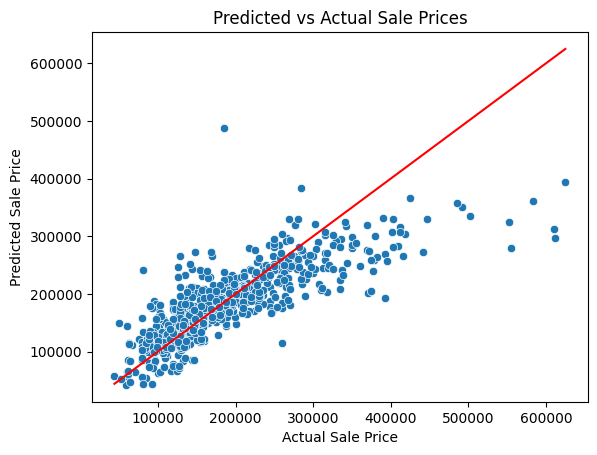

In [23]:
# Generate an error plot to visualise the differences between the predicted and actual values in the test set.
plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Predicted vs Actual Sale Prices")

The error plot compares predicted sale prices against actual values from the test set. The red diagonal line represents perfect predictions, where predicted values equal actual values. Most points fall below this line, indicating that the model tends to underpredict sale prices. While the scatter shows that the model captures the general upward trend, the consistent gap below the line highlights systematic error. This visual evidence supports the RMSE result, showing that although the model explains part of the variation in housing prices, it misses other important factors.

## Residual Plot

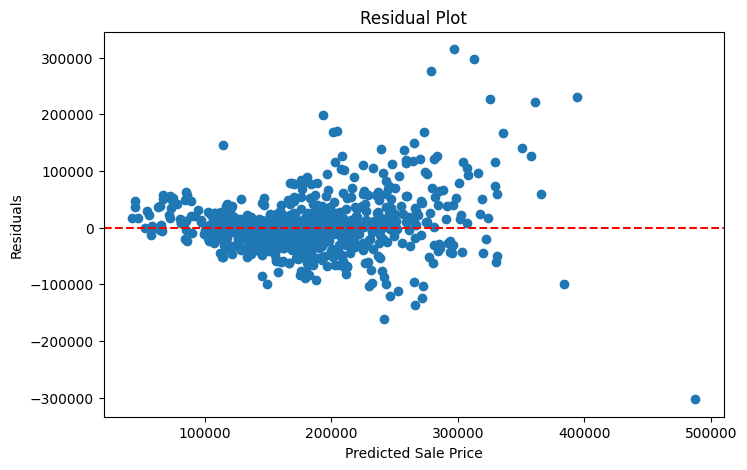

In [27]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot reveals that the spread of the residuals increases as the predicted sale price increases, indicating heteroscedasticity. This suggests that the model's prediction errors become larger for more expensive homes, violating the constant variance assumption of linear regression.

The plot also shows a tendency to underpredict higher-priced properties, particularly those with predicted sale prices above approximately $250,000. This suggests that the model does not fully capture the characteristics of luxury homes, likely because important explanatory variables such as location, property quality, or other premium features were not included.

Several observations exhibit unusually large residuals, including one property that was substantially overpredicted and others that were significantly underpredicted. These observations may represent outliers or properties with unique characteristics that are not well explained by the current model.

Although the residual variance increases with higher predicted prices, there is no strong curved pattern in the residuals. This suggests that the overall linear relationship is appropriate, but that the model would benefit from improvements to better account for high-value properties and reduce prediction error.

## Conclusion

This project developed a multiple linear regression model to predict house sale prices in the Ames Housing dataset using above-ground living area (Gr_Liv_Area) and garage area (Garage_Area) as predictor variables. The workflow included data cleaning, exploratory data analysis, feature selection, model training, and model evaluation.

The exploratory data analysis identified positive relationships between both predictor variables and sale price, supporting their selection for the regression model. The model achieved an R² score of 0.639, indicating that approximately 63.9% of the variation in house sale prices was explained by the selected features. The evaluation metrics showed that the model provides reasonably accurate predictions, although prediction errors increase for some properties.

The residual analysis revealed evidence of heteroscedasticity, with prediction errors becoming larger for higher-priced homes. The model also tended to underpredict more expensive properties, suggesting that important factors influencing premium house prices were not captured by the two selected predictor variables. While the residuals did not display a strong curved pattern, indicating that a linear relationship is generally appropriate, several notable outliers were identified and warrant further investigation.

Overall, the model demonstrates that above-ground living area and garage area are important predictors of house sale prices, but additional variables would likely improve predictive performance. Future work could include applying a logarithmic transformation to the target variable, incorporating additional housing characteristics such as neighbourhood and overall quality, investigating influential outliers, and comparing the performance of alternative regression models such as Ridge and Lasso Regression.